# Healthcare Demand Intelligence & Planning

## Step 1 — Data Audit and Exploratory Analysis

### Objective

Understand the structure, quality and statistical properties
of historical pharmaceutical demand before developing forecasting models.

### Key questions

1. What does demand look like over time?
2. Is there a trend?
3. Is there seasonality?
4. How variable is demand?
5. Are there outliers or anomalous periods?
6. Is demand autocorrelated?
7. Does demand behavior differ by region/product?
8. Are there data-quality issues that could affect forecasting?

In [1]:
from google.colab import userdata
userdata.get('GITHUB_Token')
!git config --global user.email "nn.sinha16@gmail.com"
!git config --global user.name "NNS1619"


In [6]:
%%writefile .gitignore
data/raw/*.csv
*.token
.env
__pycache__/

Writing .gitignore


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("global_pharmacy_sales_2020_2025_daily_dataset.csv")


Saving global_pharmacy_sales_2020_2025_daily_dataset.csv to global_pharmacy_sales_2020_2025_daily_dataset.csv


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Rows: 177990
Columns: 14

Column names:
['date', 'year', 'month', 'day', 'region', 'country', 'category', 'medicine', 'age_group', 'units_sold', 'unit_price', 'stock_level', 'expiry_days_remaining', 'covid_flag']

Data types:


,dtype
date,object
year,int64
month,int64
day,int64
region,object
country,object
category,object
medicine,object
age_group,object
units_sold,int64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("global_pharmacy_sales_2020_2025_daily_dataset.csv")


Saving global_pharmacy_sales_2020_2025_daily_dataset.csv to global_pharmacy_sales_2020_2025_daily_dataset.csv


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Rows: 177990
Columns: 14

Column names:
['date', 'year', 'month', 'day', 'region', 'country', 'category', 'medicine', 'age_group', 'units_sold', 'unit_price', 'stock_level', 'expiry_days_remaining', 'covid_flag']

Data types:


,dtype
date,object
year,int64
month,int64
day,int64
region,object
country,object
category,object
medicine,object
age_group,object
units_sold,int64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("global_pharmacy_sales_2020_2025_daily_dataset.csv")


Saving global_pharmacy_sales_2020_2025_daily_dataset.csv to global_pharmacy_sales_2020_2025_daily_dataset.csv


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Rows: 177990
Columns: 14

Column names:
['date', 'year', 'month', 'day', 'region', 'country', 'category', 'medicine', 'age_group', 'units_sold', 'unit_price', 'stock_level', 'expiry_days_remaining', 'covid_flag']

Data types:


,dtype
date,object
year,int64
month,int64
day,int64
region,object
country,object
category,object
medicine,object
age_group,object
units_sold,int64


In [4]:
display(df.head(25))

,date,year,month,day,region,country,category,medicine,age_group,units_sold,unit_price,stock_level,expiry_days_remaining,covid_flag
0,2025-10-12,2025,10,12,Middle East,UAE,Chronic,Amlodipine,0-12,328,45.38,4774,466,0
1,2020-09-15,2020,9,15,South Asia,India,Chronic,Amlodipine,26-45,371,75.49,4584,181,1
2,2020-02-26,2020,2,26,Middle East,UAE,Vitamin,Vitamin C,0-12,948,22.51,3934,556,1
3,2025-11-09,2025,11,9,South Asia,Sri Lanka,Chronic,Amlodipine,0-12,275,63.29,4544,330,0
4,2022-04-04,2022,4,4,South America,Argentina,Chronic,Amlodipine,26-45,563,44.28,4284,590,0
5,2021-02-19,2021,2,19,South America,Argentina,Chronic,Metformin,26-45,642,80.61,4372,108,1
6,2023-08-13,2023,8,13,South America,Argentina,Antibiotic,Azithromycin,65+,243,15.81,4701,221,0
7,2023-05-21,2023,5,21,North America,Canada,Chronic,Metformin,13-25,273,50.79,4613,362,0
8,2024-08-13,2024,8,13,Oceania,New Zealand,Cough_Cold,Cough Syrup,46-65,223,90.92,4757,621,0
9,2022-11-04,2022,11,4,South Asia,India,Chronic,Amlodipine,65+,369,68.47,4524,174,0


In [5]:
df["date"] = pd.to_datetime(df["date"])

print("Start date:", df["date"].min())
print("End date:", df["date"].max())

print("Number of unique dates:", df["date"].nunique())

Start date: 2020-01-01 00:00:00
End date: 2025-12-31 00:00:00
Number of unique dates: 2192


In [6]:
expected_dates = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="D"
)

missing_dates = expected_dates.difference(
    df["date"].drop_duplicates()
)

print("Expected number of dates:", len(expected_dates))
print("Observed number of dates:", df["date"].nunique())
print("Missing dates:", len(missing_dates))

Expected number of dates: 2192
Observed number of dates: 2192
Missing dates: 0


In [7]:
missing = (
    df.isna()
      .sum()
      .to_frame("missing_count")
)

missing["missing_percent"] = (
    missing["missing_count"] / len(df) * 100
)

display(
    missing.sort_values(
        "missing_percent",
        ascending=False
    )
)

,missing_count,missing_percent
date,0,0.0
year,0,0.0
month,0,0.0
day,0,0.0
region,0,0.0
country,0,0.0
category,0,0.0
medicine,0,0.0
age_group,0,0.0
units_sold,0,0.0


In [8]:
print("Duplicate rows:", df.duplicated().sum())
key_columns = [
    "date",
    "country",
    "medicine",
    "age_group"
]

duplicates = df.duplicated(
    subset=key_columns,
    keep=False
)

print("Potential logical duplicates:", duplicates.sum())

Duplicate rows: 2630
Potential logical duplicates: 5260


In [9]:
categorical_columns = [
    "region",
    "country",
    "category",
    "medicine",
    "age_group"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts())


--- region ---
Unique values: 8
region
East Asia        22275
Middle East      22268
Africa           22263
Oceania          22262
South America    22251
Europe           22250
North America    22216
South Asia       22205
Name: count, dtype: int64

--- country ---
Unique values: 19
country
Brazil          11334
USA             11173
Nigeria         11151
Saudi Arabia    11148
Australia       11143
UAE             11120
New Zealand     11119
Kenya           11112
Canada          11043
Argentina       10917
South Korea      7578
Sri Lanka        7485
Bangladesh       7456
Germany          7433
France           7424
China            7408
UK               7393
Japan            7289
India            7264
Name: count, dtype: int64

--- category ---
Unique values: 5
category
Chronic        35614
Antibiotic     35610
Antipyretic    35604
Vitamin        35595
Cough_Cold     35567
Name: count, dtype: int64

--- medicine ---
Unique values: 10
medicine
Amlodipine      17828
Amoxicillin     17811

In [10]:
numeric_columns = [
    "units_sold",
    "unit_price",
    "stock_level",
    "expiry_days_remaining"
]

display(
    df[numeric_columns]
      .describe()
      .T
)

,count,mean,std,min,25%,50%,75%,max
units_sold,177990.0,447.913849,338.924528,31.0,284.00,387.0,529.00,8704.0
unit_price,177990.0,52.554729,27.421909,5.0,28.77,52.6,76.31,100.0
stock_level,177990.0,4552.991780,346.608511,0.0,4443.00,4598.0,4735.00,5124.0
expiry_days_remaining,177990.0,374.038109,199.759193,30.0,200.00,374.0,547.00,720.0


Zero sales: 0
Negative sales: 0
Minimum units sold: 31
Maximum units sold: 8704


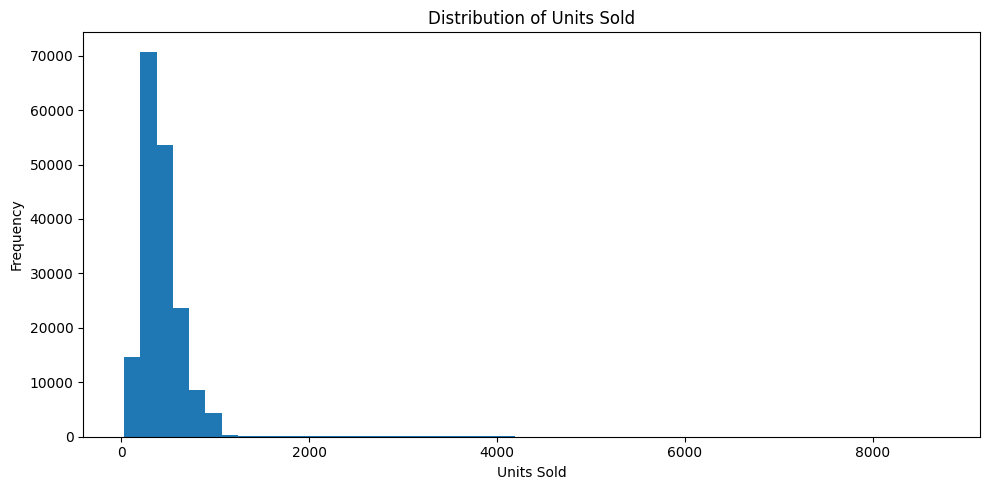

In [11]:
print("Zero sales:", (df["units_sold"] == 0).sum())
print("Negative sales:", (df["units_sold"] < 0).sum())

print(
    "Minimum units sold:",
    df["units_sold"].min()
)

print(
    "Maximum units sold:",
    df["units_sold"].max()
)
plt.figure(figsize=(10, 5))

plt.hist(
    df["units_sold"],
    bins=50
)

plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [12]:
from scipy.stats import skew

sales = df["units_sold"]

print("Mean:", sales.mean())
print("Median:", sales.median())
print("Standard deviation:", sales.std())
print("Skewness:", skew(sales))
q1 = sales.quantile(0.25)
q3 = sales.quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = df[
    (df["units_sold"] < lower_bound) |
    (df["units_sold"] > upper_bound)
]

print("Potential outliers:", len(outliers))
print("Percentage:", len(outliers) / len(df) * 100)

Mean: 447.91384909264565
Median: 387.0
Standard deviation: 338.92452821641524
Skewness: 7.647330777895798
Q1: 284.0
Q3: 529.0
IQR: 245.0
Lower bound: -83.5
Upper bound: 896.5
Potential outliers: 6899
Percentage: 3.876060452834429


In [13]:
display(
    df.nlargest(20, "units_sold")[
        [
            "date",
            "region",
            "country",
            "category",
            "medicine",
            "age_group",
            "units_sold",
            "unit_price",
            "stock_level",
            "covid_flag"
        ]
    ]
)


,date,region,country,category,medicine,age_group,units_sold,unit_price,stock_level,covid_flag
32967,2021-02-16,South Asia,Sri Lanka,Antibiotic,Amoxicillin,0-12,8704,53.77,0,1
111797,2020-04-13,South America,Brazil,Antipyretic,Ibuprofen,0-12,8368,67.36,0,1
1032,2021-03-29,North America,USA,Chronic,Amlodipine,26-45,8256,54.49,0,1
172403,2020-03-10,Oceania,New Zealand,Cough_Cold,Cough Syrup,13-25,8136,15.29,0,1
3325,2021-03-18,Middle East,UAE,Chronic,Metformin,13-25,7868,51.90,0,1
151413,2021-03-08,Middle East,UAE,Cough_Cold,Cough Syrup,46-65,7840,22.99,0,1
82836,2020-04-23,South Asia,Bangladesh,Cough_Cold,Cough Syrup,0-12,7688,31.00,0,1
138744,2020-04-18,Africa,Nigeria,Cough_Cold,Cough Syrup,0-12,7648,87.09,0,1
123337,2021-04-23,East Asia,China,Vitamin,Vitamin C,0-12,7592,70.02,0,1
50516,2021-05-22,Europe,UK,Cough_Cold,Cetirizine,46-65,7544,39.34,0,1


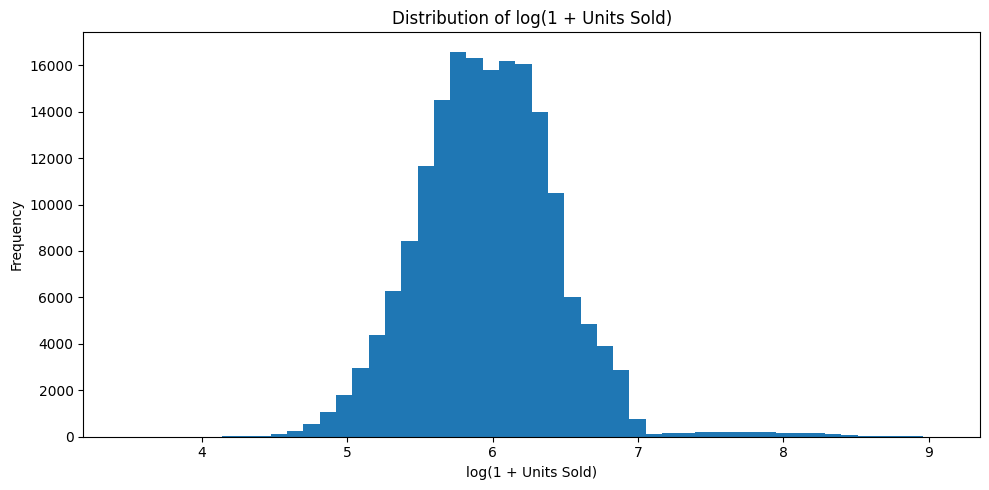

In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    np.log1p(df["units_sold"]),
    bins=50
)

plt.title("Distribution of log(1 + Units Sold)")
plt.xlabel("log(1 + Units Sold)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

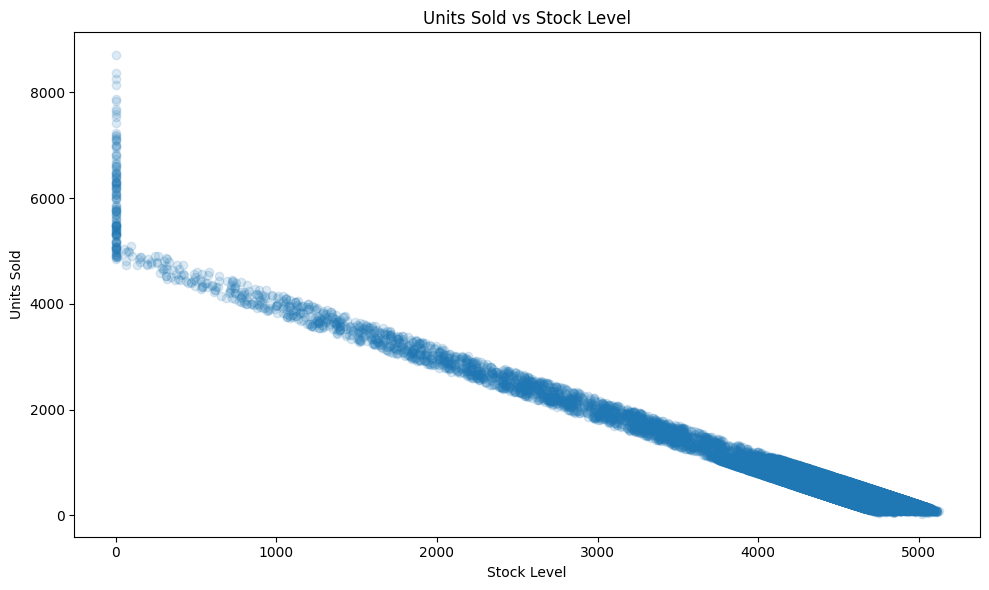

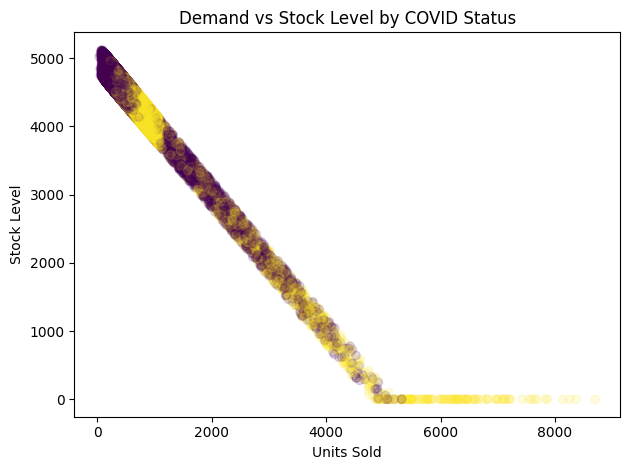

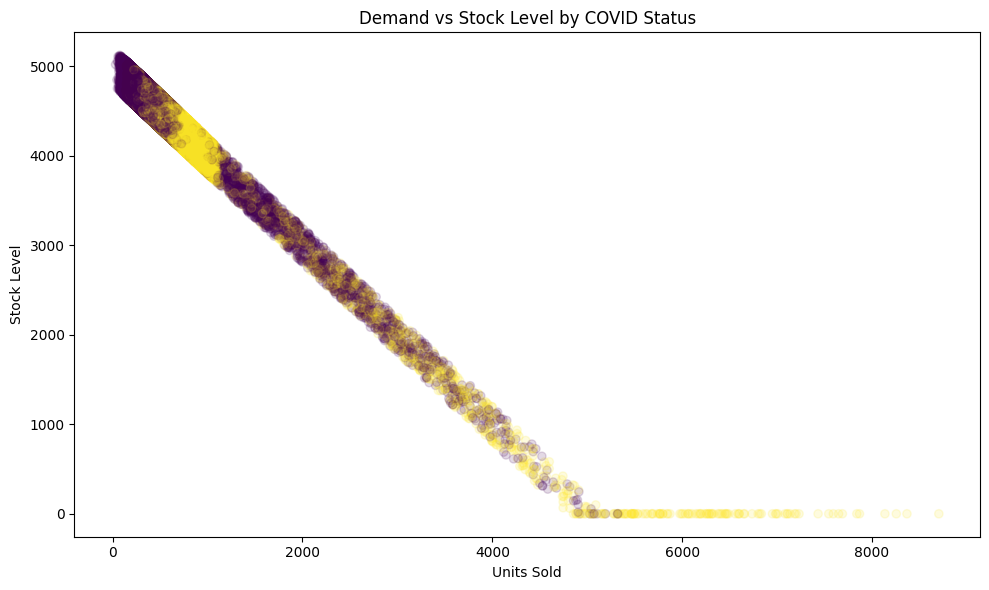

In [18]:
outlier_flag = df["units_sold"] > upper_bound

pd.crosstab(
    outlier_flag,
    df["covid_flag"],
    normalize="index"

)
df.groupby("covid_flag")["units_sold"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)
df.groupby(outlier_flag)["stock_level"].agg(
    ["count", "mean", "median", "min", "max"]
)
pd.crosstab(
    outlier_flag,
    df["stock_level"] == 0,
    normalize="index"
)
plt.figure(figsize=(10, 6))

plt.scatter(
    df["stock_level"],
    df["units_sold"],
    alpha=0.15
)

plt.xlabel("Stock Level")
plt.ylabel("Units Sold")
plt.title("Units Sold vs Stock Level")

plt.tight_layout()

plt.show()



In [21]:
covid_summary = (
    df.groupby("covid_flag")["units_sold"]
      .agg(
          count="count",
          mean="mean",
          median="median",
          std="std",
          min="min",
          max="max"
      )
)

display(covid_summary)

,count,mean,median,std,min,max
covid_flag,,,,,,
0,118627,372.924604,332.0,258.325291,31,5320
1,59363,597.767279,529.0,421.157983,140,8704


/tmp/ipykernel_1334/1702300085.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


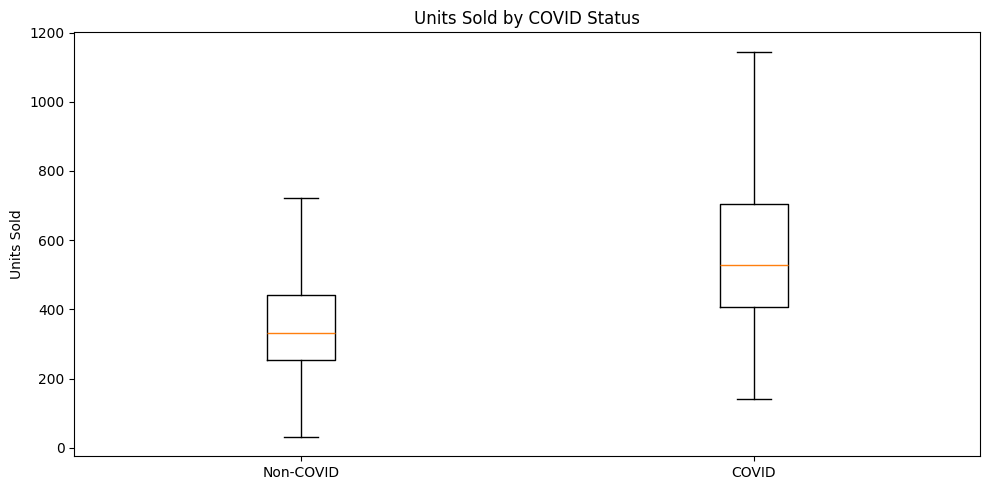

,medicine,covid_flag,mean,median,std,count
0,Amlodipine,0,370.350660,333.0,234.904557,11889
1,Amlodipine,1,597.644553,533.0,409.364409,5939
2,Amoxicillin,0,373.169827,331.0,268.800686,11865
3,Amoxicillin,1,585.193912,521.0,385.393006,5946
4,Azithromycin,0,374.994014,333.0,254.126121,11861
5,Azithromycin,1,601.633041,529.0,410.075142,5938
6,Cetirizine,0,371.501054,332.0,254.214020,11861
7,Cetirizine,1,595.767493,534.0,398.114460,5931
8,Cough Syrup,0,371.940630,332.0,257.865521,11841
9,Cough Syrup,1,598.569262,533.0,435.865677,5934


In [22]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    [
        df.loc[df["covid_flag"] == 0, "units_sold"],
        df.loc[df["covid_flag"] == 1, "units_sold"]
    ],
    labels=["Non-COVID", "COVID"],
    showfliers=False
)

plt.title("Units Sold by COVID Status")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()
covid_medicine = (
    df.groupby(["medicine", "covid_flag"])["units_sold"]
      .agg(["mean", "median", "std", "count"])
      .reset_index()
)

display(covid_medicine)

In [24]:
from scipy.stats import mannwhitneyu

non_covid = df.loc[
    df["covid_flag"] == 0,
    "units_sold"
]

covid = df.loc[
    df["covid_flag"] == 1,
    "units_sold"
]

stat, p_value = mannwhitneyu(
    non_covid,
    covid,
    alternative="two-sided"
)

print("Mann–Whitney U statistic:", stat)
print(f"p-value: {p_value:.5f}")

Mann–Whitney U statistic: 1425426286.0
p-value: 0.00000


In [25]:
covid_summary = (
    df.groupby("covid_flag")["units_sold"]
      .agg(["count", "mean", "median", "std", "min", "max"])
)

display(covid_summary)
covid_medicine = (
    df.groupby(["medicine", "covid_flag"])["units_sold"]
      .agg(["mean", "median", "std", "count"])
      .reset_index()
)

display(covid_medicine)

,count,mean,median,std,min,max
covid_flag,,,,,,
0,118627,372.924604,332.0,258.325291,31,5320
1,59363,597.767279,529.0,421.157983,140,8704


,medicine,covid_flag,mean,median,std,count
0,Amlodipine,0,370.350660,333.0,234.904557,11889
1,Amlodipine,1,597.644553,533.0,409.364409,5939
2,Amoxicillin,0,373.169827,331.0,268.800686,11865
3,Amoxicillin,1,585.193912,521.0,385.393006,5946
4,Azithromycin,0,374.994014,333.0,254.126121,11861
5,Azithromycin,1,601.633041,529.0,410.075142,5938
6,Cetirizine,0,371.501054,332.0,254.214020,11861
7,Cetirizine,1,595.767493,534.0,398.114460,5931
8,Cough Syrup,0,371.940630,332.0,257.865521,11841
9,Cough Syrup,1,598.569262,533.0,435.865677,5934


## Time Dimension Analysis: Trend, Seasonality, and Autocorrelation

### Overall Trend of Units Sold Over Time

First, let's look at the overall trend of `units_sold` over the entire period. We'll aggregate the data by date to get daily total sales and visualize it.

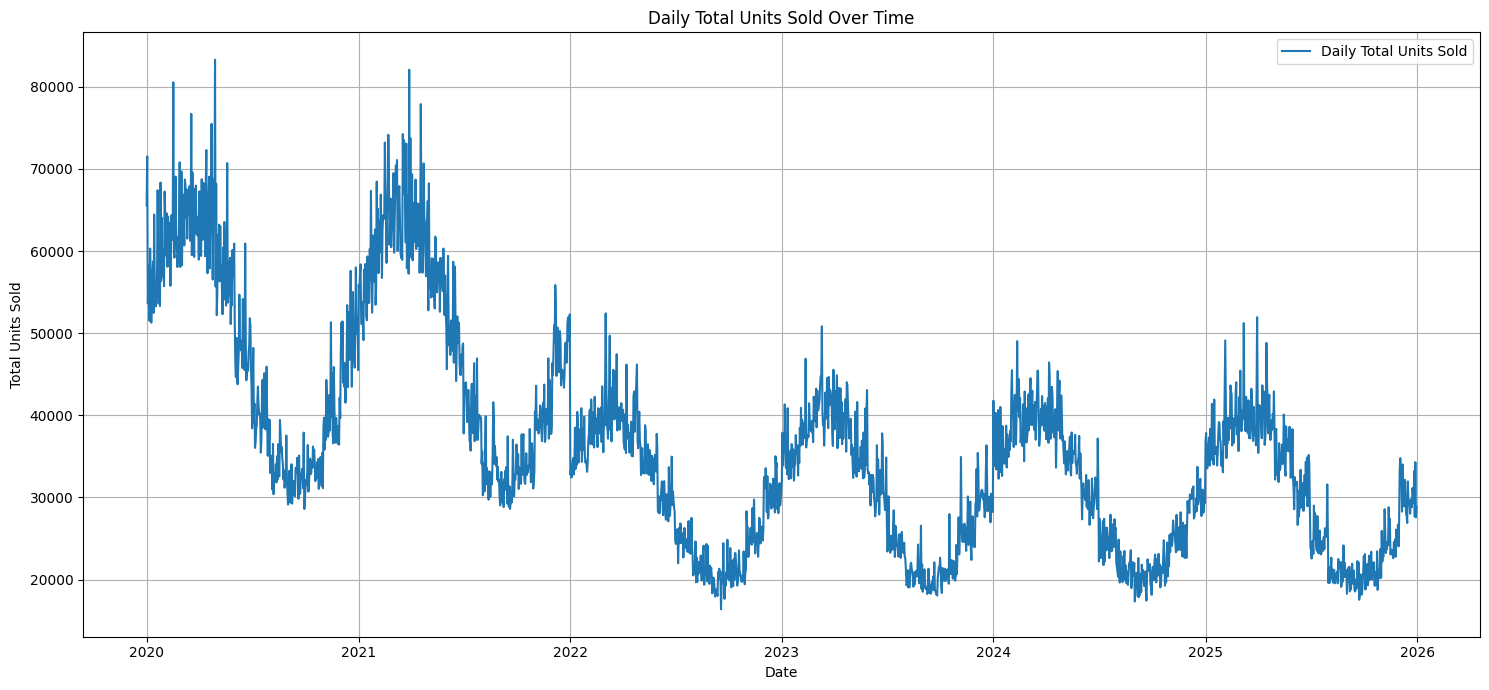

In [26]:
daily_sales = df.groupby('date')['units_sold'].sum().reset_index()

plt.figure(figsize=(15, 7))
plt.plot(daily_sales['date'], daily_sales['units_sold'], label='Daily Total Units Sold')
plt.title('Daily Total Units Sold Over Time')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Seasonality Analysis

To identify seasonality, we can extract features like month and day of the week from the `date` column and visualize the average `units_sold` for each. This can reveal monthly or weekly patterns.

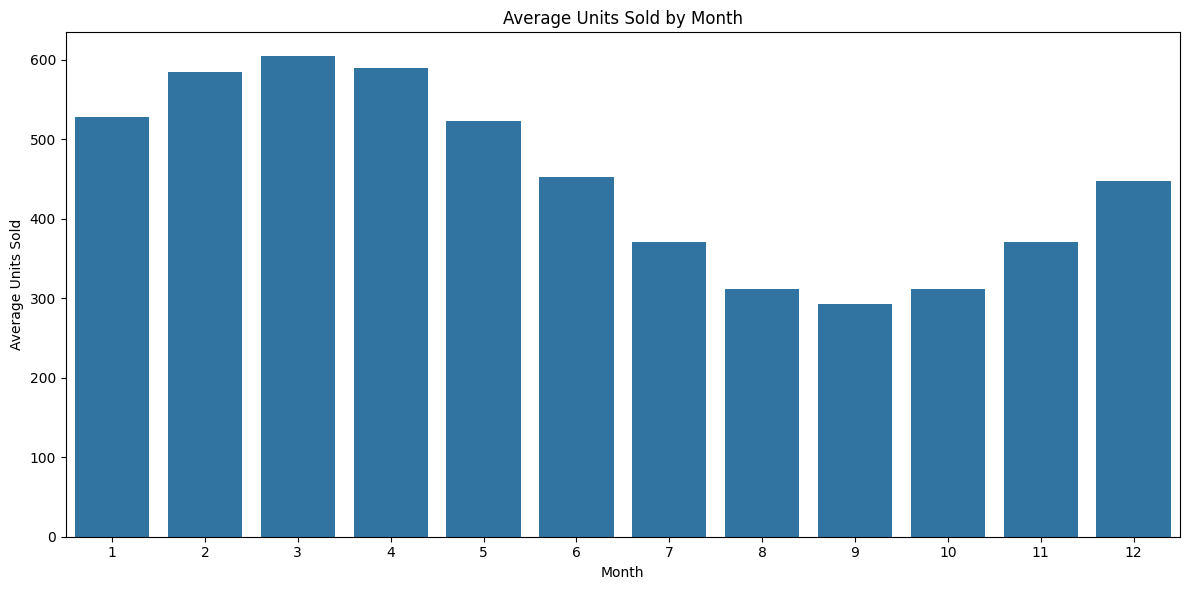

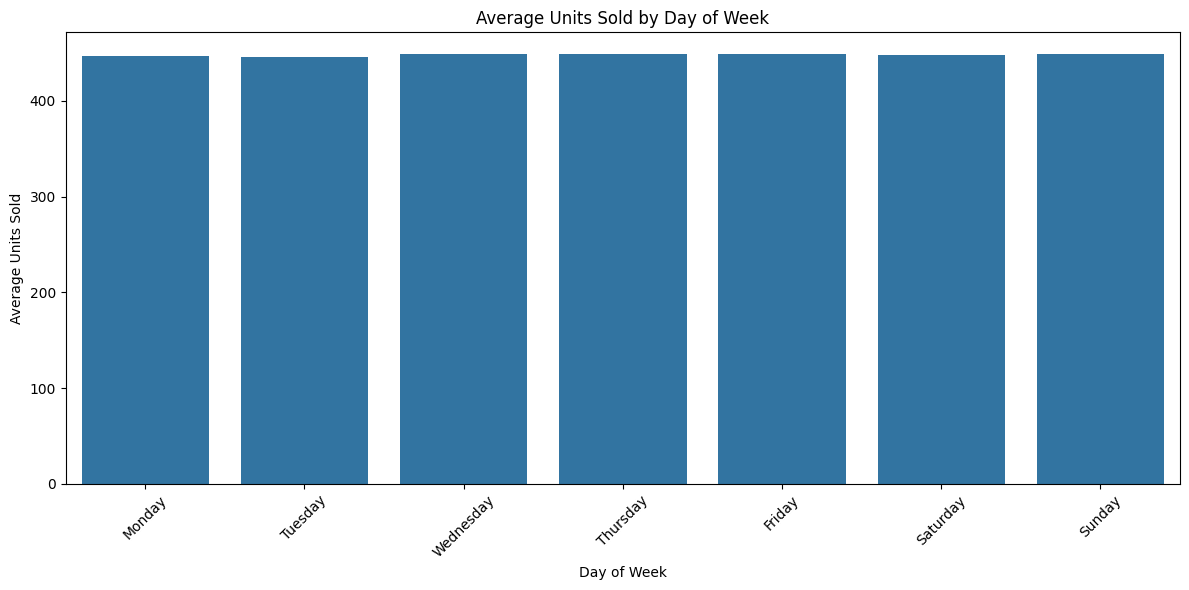

In [29]:
import seaborn as sns

df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek # Monday=0, Sunday=6

# Average units sold by month
monthly_avg_sales = df.groupby('month')['units_sold'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='month', y='units_sold', data=monthly_avg_sales)
plt.title('Average Units Sold by Month')
plt.xlabel('Month')
plt.ylabel('Average Units Sold')
plt.tight_layout()
plt.show()

# Average units sold by day of week
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg_sales = df.groupby('day_of_week')['units_sold'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='day_of_week', y='units_sold', data=daily_avg_sales)
plt.xticks(ticks=range(7), labels=day_names, rotation=45)
plt.title('Average Units Sold by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Units Sold')
plt.tight_layout()
plt.show()

### Autocorrelation Analysis

Autocorrelation measures the relationship between a variable's current value and its past values. This is crucial for time series forecasting. We will use `statsmodels` to plot the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF).

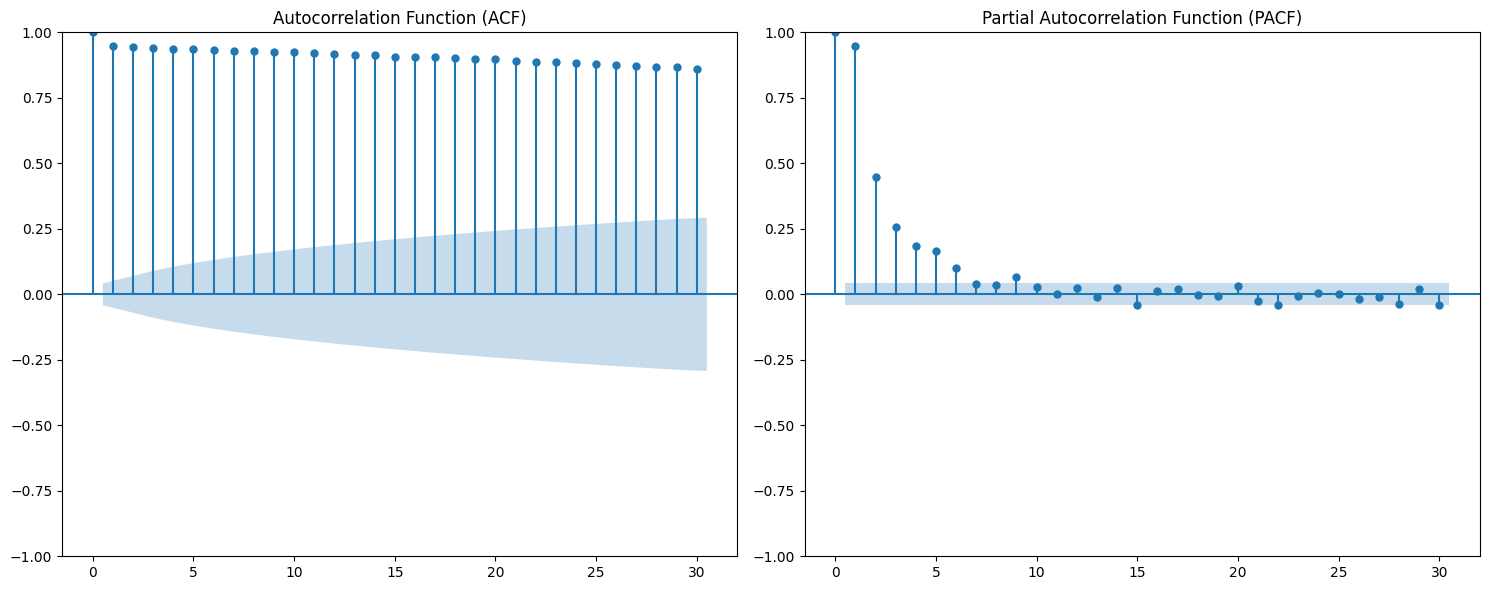

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Resample daily sales to get a clean time series for ACF/PACF
# We'll use the 'daily_sales' DataFrame created earlier
# Ensure the date column is set as index
daily_sales_indexed = daily_sales.set_index('date')

plt.figure(figsize=(15, 6))
plt.subplot(121)
plot_acf(daily_sales_indexed['units_sold'], lags=30, ax=plt.gca())
plt.title('Autocorrelation Function (ACF)')

plt.subplot(122)
plot_pacf(daily_sales_indexed['units_sold'], lags=30, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()